<a href="https://colab.research.google.com/github/limjueun06/202604-data-journalism/blob/main/ex01_%ED%85%8D%EC%8A%A4%ED%8A%B8%EB%A7%88%EC%9D%B4%EB%8B%9D%EA%B8%B0%EC%B4%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 단축키 정리
# 1. 아래로 셀 추가 : Ctrl + M + B
# 2. 아래로 셀 추가 : Ctrl + M + A
# 3. 셀 삭제 : Ctrl + M + D
# 4. 마크다운 전환 : Ctrl + M + M
# 5. 코드 셀 전환 : Ctrl + M + Y
# 6. 자동완성 : Ctrl + Space
# 7. 실행 : Ctrl + ENTER
# 8. 실행 후 아래 셀 이동 : Shift + ENTER
# 9. 마크다운 실행 : Alt + ENTER

### Text Mining
- 비정형 데이터(ex.텍스트)에서 의미있는 데이터만 추출하는 작업
- 자연어 처리 기술도 접목해서 최근 많이 수행되고 있음.
  - 자연어 처리 : 사람의 언어(텍스트, 음성)를 컴퓨터가 이해 할 수 있도록 처리하는 일련의 과정

### Text Minig Process
1. 텍스트 수집
2. 정제(전처리)
3. 토큰화
4. 수치화
5. 분석 및 적용

In [ ]:
# 드라이브 마운트 : colab에서 구글 드라이브 접근하도록 연결해주는 작업
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 현재 위치 파악하기!
!pwd

/content


In [ ]:
# 초기 경로 설정하기
%cd /content/drive/MyDrive/Colab Notebooks/동아3기_텍스트마이닝

/content/drive/MyDrive/Colab Notebooks/동아3기_텍스트마이닝


In [ ]:
!pwd

/content/drive/MyDrive/Colab Notebooks/동아3기_텍스트마이닝


### 데이터 수집 및 로딩
- https://github.com/smilegate-ai/korean_unsmile_dataset
- 스마일게이트의 한국어 혐오표현 데이터셋 활용

In [ ]:
# 필요한 라이브러리 불러오기
import pandas as pd

In [ ]:
# 훈련용 / 평가용 데이터 로딩
# train = pd.read_csv("파일경로/파일명.확장자", delimiter = "구분기호")
train = pd.read_csv("./data/unsmile_train_v1.0.tsv", delimiter = "\t")
test = pd.read_csv("./data/unsmile_valid_v1.0.tsv", delimiter = "\t")


In [ ]:
# 상위 5개 데이터 확인해보기
display(train.head())
display(test.head())

,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭
0,일안하는 시간은 쉬고싶어서 그런게 아닐까,0,0,0,0,0,0,0,0,0,1,0
1,아동성범죄와 페도버는 기록바 끊어져 영원히 고통 받는다. 무슬림 50퍼 근친이다. ...,0,0,0,0,0,0,1,0,0,0,0
2,루나 솔로앨범 나왔을 때부터 머모 기운 있었음 ㅇㅇ Keep o doin 진짜 띵...,0,0,0,0,0,0,0,0,0,1,0
3,홍팍에도 어버이연합인가 보내요 뭐 이런뎃글 있는데 이거 어버이연합측에 신고하면 그쪽...,0,0,0,0,0,0,0,0,0,1,0
4,아놔 왜 여기 댓들은 다 여자들이 김치녀라고 먼저 불렸다! 여자들은 더 심하게 그런...,1,0,0,0,0,0,0,0,0,0,0


,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭
0,ㅇㄱㄹㅇ 진짜 죽어도 상관없다는 마인드로 싸웠더니 지금 서열 상타취노 식칼들고 니가...,0,1,0,0,0,0,0,0,0,0,0
1,여자들은 취미가 애낳는건가.. 취미를 좀 가져라,1,0,0,0,0,0,0,0,0,0,0
2,개슬람녀 다 필요없고 니 엄마만 있으면 된다,0,0,0,1,0,0,1,0,0,0,0
3,조팔ㅋㅋ 남한 길거리 돌아다니면 한국남자때문에 눈재기하는데 그걸 내 폰에 굳이 담아...,0,1,0,0,0,0,0,0,0,0,0
4,바지 내리다 한남들 와꾸 보고 올려뿟노,0,1,0,0,0,0,0,0,0,0,0


### 1. 빈도분석
- 특정 혐오표현에서 많이 사용되는 단어들을 뭐가 있을까?

In [ ]:
# 지역이 1인 데이터만 추출해서 문장을 살펴보자
text_train = train[train['지역'] == 1 ]['문장']
text_train

,문장
6,예수 십새끼 개새끼 창녀아들 애비실종 가정교육 못받은 무뇌충 허언증 정신병자 사기꾼...
25,홍어무침 ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ
28,홍들 피들 폭들 ㅎㅎㅎ
35,이새끼 전라도
37,진짜 전라도 존나 싫다
...,...
14956,경상도새끼네
14975,7시말은 왜이렇게 듣기가 싫냐. 식당 같은데 가서도 전라도 말 들리면 신경 엄청 곤...
14979,왜 재밌겠는데 뭘 섬라도 쪽 꿀잼뉴스 공중제비하고 보겠네
14998,전라디언은 뇌구조가 다르게 태어난당께


In [ ]:
# 띄어쓰기 중심으로 토큰화
# 리스트 컴프리핸션
area_tokens = [t for doc in text_train for t in doc.split(" ")]

In [ ]:
# 위의 코드와 동일한 반복문
tokens = []
for doc in text_train :     # 전체 데이터에서 한 문장만 뽑아오기
  for t in doc.split(" ") : # 뽑아온 문장을 공백 단위로 쪼개주기
    tokens.append(t)        # 빈 리스트에 차곡차곡 저장

In [ ]:
# 단어의 빈도를 세보기
from collections import Counter

In [ ]:
# 카운터 도구를 활용해서 같은 단어들의 갯수 세기
counter = Counter(area_tokens)

In [ ]:
# 상위 40개의 단어를 확인해보자
counter.most_common(40)

[('전라도', 130),
 ('홍어', 48),
 ('존나', 40),
 ('진짜', 39),
 ('경상도', 38),
 ('새끼들', 33),
 ('다', 33),
 ('ㅋㅋㅋ', 30),
 ('ㅋㅋ', 29),
 ('전라도는', 27),
 ('쌍도', 26),
 ('더', 26),
 ('=', 25),
 ('개쌍도', 20),
 ('왜', 19),
 ('씨발', 19),
 ('시발', 18),
 ('서울', 18),
 ('그', 17),
 ('ㄹㅇ', 16),
 ('이', 15),
 ('전라도가', 15),
 ('사는', 15),
 ('저', 14),
 ('역시', 14),
 ('.', 14),
 ('제일', 13),
 ('라도', 13),
 ('홍어들', 13),
 ('그냥', 13),
 ('대구', 12),
 ('일베', 12),
 ('홍어가', 12),
 ('보면', 12),
 ('+', 12),
 ('있는', 11),
 ('좀', 11),
 ('뭐', 11),
 ('홍어새끼들', 10),
 ('전라도에', 10)]

In [ ]:
# 글꼴 설치
# 나눔 폰트 사용
# 시스템에 나눔폰트 전체를 설치하겠다.
# -y 옵션은 설치시 사용자에게 확인을 요구하지 않고 자동으로 설치 진행
!apt-get install -y fonts-nanum*

# 설치된 폰트를 시스템 폰트 캐시에 등록
# fc-cache -fv 명령은 폰트 캐시를 강제로 새로고침해서 반영시키는 명령어
!sudo fc-cache -fv

# Matplotlib의 캐시 삭제
# ~/.cache/matplotlib 폴더에 저장된 캐시파일들을 모두제거
# 이 작업은 새로운 폰트가 적용되지 않을때 문제를 해결하는데 유용
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'fonts-nanum-extra' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-coding' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-eco' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum' for glob 'fonts-nanum*'
The following NEW packages will be installed:
  fonts-nanum fonts-nanum-coding fonts-nanum-eco fonts-nanum-extra
0 upgraded, 4 newly installed, 0 to remove and 37 not upgraded.
Need to get 46.0 MB of archives.
After this operation, 177 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-coding all 2.5-3 [4,988 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-eco all 1.000-7 [14.7 MB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-extra all 20200506-1 [21.0

- 글꼴을 설치 했다면 세션 반영을 위해 세션 재시작이 필요하다.

In [ ]:
# 워드 클라우드 라이브러리 설치하기
!pip install wordcloud

In [ ]:
# 워드 클라우드 불러오기
from wordcloud import WordCloud

In [ ]:
# 객체 생성 단계
wc = WordCloud(background_color='white', # 배경색은 흰색
               random_state = 715, # 랜덤 값 고정
               font_path='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 글꼴 설정
               )

In [ ]:
# 쪼개진 토큰을 하나의 문자열로 합치겠습니다.
input_str = ' '.join(area_tokens)

In [ ]:
# 문자열로부터 워드클라우드 생성
wc_rs = wc.generate_from_text(input_str)

In [ ]:
# 시각화
from matplotlib import pyplot as plt
plt.rc('font', family='NanumBarunGothic') # Matplotlib 글꼴 설정

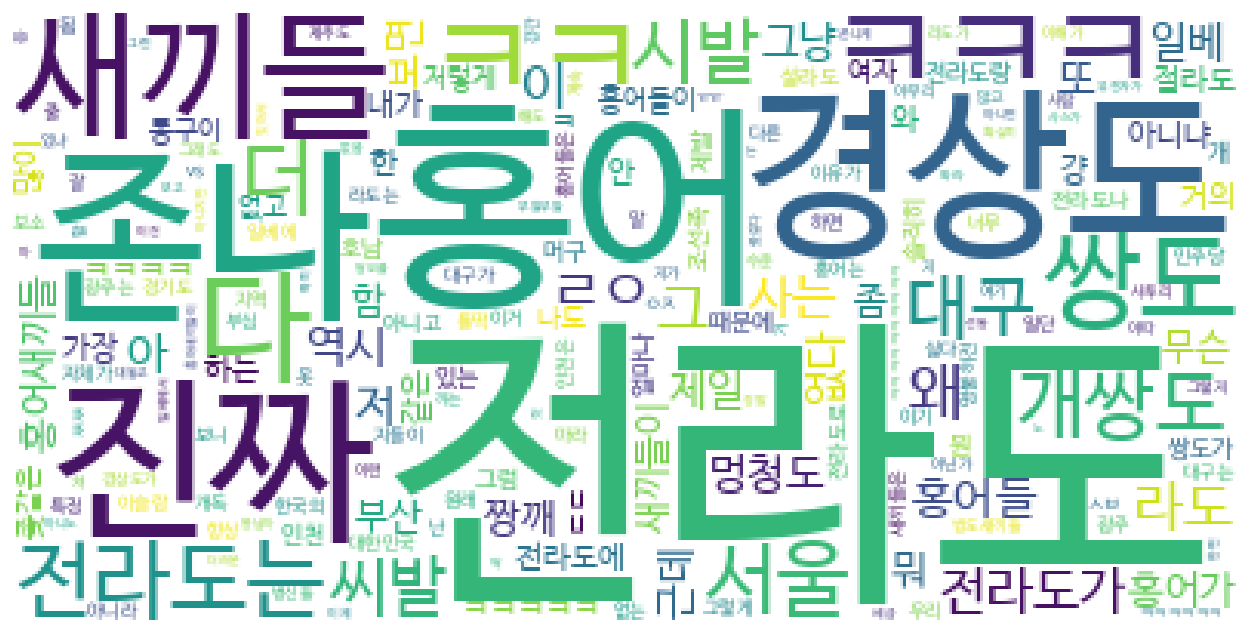

In [ ]:
plt.figure(figsize = (20,8)) # 그래프 사이즈 조절
plt.imshow(wc_rs) # 워드클라우드 이미지로 출력해주세요
plt.axis('off') # 축에 있는 눈금값 삭제 하겠습니다.
plt.savefig('./data/지역혐오.png') # 그래프 파일 저장
plt.show()

# 출력 분석
# '전라도는'이나 '전라도가'는 같은 의미를 가지는 단어임에도 불구하고 조사로인해 컴퓨터가 다르게 받아들인다.
# '아', '걍', '와' 같은 분석에 불필요한 용어들이 존재 -> 불용어

# 실제 빈도분석을 진행 할 때 데이터를 깔끔하게 정리하는 프로세스가 필요하다 -> 전처리(정제)

### 2. 텍스트 분류
- 텍스트 마이닝 프로세스를 활용해보자.

### 정제(Cleaning)
- 불용어 제거 : 불필요한 단어(또는 토큰)를 제거하는 작업
- 어간 추출 : 단어 핵심 부분만 추출
- 표준어화 : 표현방법을 표준어에 맞춰서 변경

** 정규 표현식(Reguler Expression)**
- 특정한 패턴(규칙)을 가진 문자열의 집합을 표현하는 언어
- 핸드폰 / 이메일처럼 패턴이 있는 문자열의 검색과 치환을 위해 프로그래밍언어에서 대부분 지원하고 있다.
- https://wikidocs.net/21703

In [ ]:
# 정규표현식 라이브러리 가져오기
import re

In [ ]:
# 전화번호 검출 예시
# re.compile() : 정규표현식을 파이썬에게 전달해주는 역할 - 정규표현식의 규칙을 파이썬에게 알려주는 함수
p = re.compile('010-?[0-9]{4}-?\\d{4}') # 전화번호 형식을 찾는 정규표현식
# '010-?[0-9]{4}-?\\d{4}' 설명
# '010' : 휴대폰 첫 세자리.
# '-?' : 하이픈(-)이 있을수도 있고 없을수도 있다.
# '[0-9]' : 0부터 9까지 숫자
# '{4}' : 숫자 4번 반복된다.
# '-?' : 하이픈(-)이 있을수도 있고 없을수도 있다.
# '\\d' : 정수 하나(한자리수의 숫자)
# '{4}' : 네번 반복된다.

# 이 규칙을 적용하면 다음과 같은 휴대폰 번호 형식을 매칭
# 1. 010-2841-8972
# 2. 0102841-8972
# 3. 010-28418972
# 4. 01028418972
# 하이픈이 들어가거나 생략된 경우 모두 매칭이 가능하다.

In [ ]:
# 규칙 적용해보기
p.search('규남쌤 전화번호 : 010-284-8972')

In [ ]:
# 규칙 적용해보기
p.search('규남쌤 전화번호 : 0102841-8972')

<re.Match object; span=(11, 23), match='0102841-8972'>

In [ ]:
# 규칙 적용해보기
p.search('규남쌤 전화번호 : 01028418972')

<re.Match object; span=(11, 22), match='01028418972'>

### 혐오표현 데이터 클렌징
- ㅋㅋㅋㅋ, ㅎㅎㅎ 같이 정해진 횟수 없이 반복되는 글자 삭제
- 한글자인 단어 삭제 (의미부여가 어려운 단어라 가정)

In [ ]:
# 패턴 생성
p = re.compile('[ㅋㅎㄷㅇ~!?.\\-ㅡ0-9a-z]+')

# 패턴 설명
# '[...]' : 대괄호 내부에 포함된 문자 중 하나와 일치하는 문자들을 의미
# 'ㅋㅎㄷㅇ' : 'ㅋ','ㅎ','ㄷ','ㅇ' 중 하나의 문자가 들어간 부분을 매칭
# (한국어에서 자주 사용하는 인터넷 표현 : ㅋㅋㅋㅋ, ㄷㄷㄷ, ㅎㅎㅎㅎ, ㅇㅇ)
# '~!?.\\-' : 틸드(~), 느낌표(!), 물음표(?), 마침표(.), 하이픈(-) 중 하나와 일치.
# \\- : \\는 이스케이프 문자를 이야기함 \-을 문자 그대로 인식하게 만들어준다.
# 'ㅡ' : 한글모음 ㅡ를 의미함. ㅡㅡ
# '0-9' : 0부터 9까지를 의미함
# 'a-z' : 소문자 a부터 z까지를 의미함.
# '+' : 해당 문자 집합이 한번이상 반복 될 수 있다.

# ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ, ㅎㅎㅎㅎㅎㅎㅎㅎㅎㅎ ,d-2, ㅋㅋ?, ㅇㅇ~
# 여러개의 한글 자모, 기호, 숫자, 소문자가 연속으로 등장하는 경우 모두 매칭

In [ ]:
# 텍스트를 전처리해서 리스트에 담아주자.
train_clean = [] # 전처리된 전체 텍스트를 담을 리스트

for doc in train['문장'] :
    temp = [] # 전처리된 문장의 토큰들이 들어갈 리스트 지정
    for token in doc.split(' ') : # 한개의 문장을 공백으로 나눠서 보겠다.
        if len(token) < 2 : # 1글자인 경우
          continue # 지나가요~
        if p.search(token) : # 정규표현식에 매칭이 되는지
          continue
        temp.append(token) # 정제된 토큰 temp라는 리스트에 쌓아주기
    train_clean.append(' '.join(temp)) # 정상적인 토큰은 전체 리스트에 추가하겠습니다.

In [ ]:
train_clean

['일안하는 시간은 쉬고싶어서 그런게 아닐까',
 '아동성범죄와 페도버는 기록바 끊어져 영원히 고통 무슬림 IQ 떨어지고 출산 위험은',
 '루나 솔로앨범 나왔을 때부터 머모 기운 있었음 진짜 띵곡임 들어보셈"',
 '홍팍에도 어버이연합인가 보내요 이런뎃글 있는데 이거 어버이연합측에 신고하면 그쪽에서 고소',
 '아놔 여기 댓들은 여자들이 김치녀라고 먼저 여자들은 심하게 이렇게 내가 둘다 나쁜 이상도 이하도 아닌데',
 '고향가서 피방가면 동네 부럴 친구들이랑은 거르는 없이 이야기하니까 말하게 되더라 당연히 키보드를 치거나 그러지는 않는데 말하는게 많이 거칠어지긴 반성해야겠네',
 '예수 십새끼 개새끼 창녀아들 애비실종 가정교육 못받은 무뇌충 허언증 정신병자 사기꾼 망상 근본없는 병신 장애인 짱개 흑인 이슬람 전라도랑 동급',
 '나이쳐먹고 피시방가는 놈들은 대가리에 똥만찬 놈들임',
 '출산청같은 우리나라 계집들 의무적으로 군대보내면 해결될 정신개조부터 지할꺼 다하고 무슨 애를 낳고 무슨 자식교육을',
 '재능 ㅂㅅㅌㅊ노 합성배우고싶다이기',
 '가짜 남자는 어떻게',
 '이슬람뺨치내',
 '어린이집에 월요일에 데려다주고 금요일에 데리고 가슴이 너무 아가가 얼마나',
 '갓슬람 정희구현 테러 ㅅㅅㅅㅅ미제양키새끼들에게는 테러가 답이다좆같은 양키 씨발새끼들',
 'AICPA 따고 넘어갔나보네',
 '리더십, 메시지로 내부 결속을 강화하고 외부로 이미지를 구축하여 다시 교회로 모일수 있기를 소망하고 기도합니다',
 '협박스킬은 패시브랑께',
 '위로와 격려를 호텔에서 저여자도 정상은 아니구만 완전 지네 할아버지보다 나이가 많을듯한데 둘다 그렇게 더러운짓은 하고 설교를 어떻게',
 '메틸 알콜 집에서 쓰고 질문 에틸에 메틸 공업용 에틸 알콜은 면세라 불법적으로 술제조 때문에 정도 메틸이 들어가면서 제조방지용으로',
 '띄울사람이 진짜 없긴 없나보다',
 '한국패미=고유정 수준',
 'CNN 구구절절 팩트',
 '빼고 아무것도 없는 개돼지 정권이노 탄핵 개힘조',
 

In [ ]:
# 텍스트를 전처리해서 리스트에 담아주자.
test_clean = [] # 전처리된 전체 텍스트를 담을 리스트

for doc in test['문장'] :
    temp = [] # 전처리된 문장의 토큰들이 들어갈 리스트 지정
    for token in doc.split(' ') : # 한개의 문장을 공백으로 나눠서 보겠다.
        if len(token) < 2 : # 1글자인 경우
          continue # 지나가요~
        if p.search(token) : # 정규표현식에 매칭이 되는지
          continue
        temp.append(token) # 정제된 토큰 temp라는 리스트에 쌓아주기
    test_clean.append(' '.join(temp)) # 정상적인 토큰은 전체 리스트에 추가하겠습니다.

In [ ]:
len(train_clean), len(test_clean)

(15005, 3737)

In [ ]:
# r'' : 원시 문자열. \를 하나만 사용하게 만듬
p = r'[^a-zA-Z0-9가-힣\s\.\?\!]'

# sub() : 치환하는 함수
re.sub(p, '', '안녕하세요 ㅋㅋㅋㅋㅋㅋㅋㅋㅋ')
# 해당 패턴을 해석해보면
# 위의 패턴이 아니라면(^) 공백으로 변환하겠다.

'안녕하세요 '

# 20260311

### 형태소 분석
- konlpy : https://konlpy.org/ko/latest/index.html

**Konlpy 내부 라이브러리 구조**
- 5개의 세부 라이브러리로 구성됨
- Mecab Github : https://github.com/SOMJANG/Mecab-ko-for-Google-Colab

| 분석기    | 속도        | 정확도        | 특징                                                         | 장단점                                                         |
|-----------|-------------|---------------|--------------------------------------------------------------|----------------------------------------------------------------|
| **Mecab** | 매우 빠름   | 높음          | - 백터 기반의 빠른 분석<br>- 대용량 데이터 처리에 적합          | + **장점:** 속도 및 효율성 우수<br>- **단점:** 설치가 다소 복잡, 사전 관리 필요 |
| **Kkma**  | 느림        | 높음          | - 문장 단위의 세밀한 분석 제공<br>- 다양한 형태소 정보 리턴       | + **장점:** 상세 분석, 문맥 파악 용이<br>- **단점:** 속도 느림, 대용량 데이터에 부적합 |
| **Hannanum** | 보통     | 중간          | - KAIST 개발 분석기로 전통적 접근법 사용<br>- 기본 문법 규칙 기반  | + **장점:** 비교적 안정적인 결과 제공<br>- **단점:** 문맥 반영 미흡, 업데이트 한계  |
| **Komoran** | 보통       | 높음          | - 최신 알고리즘 일부 적용<br>- 딥러닝 요소 도입 가능             | + **장점:** 높은 정확도, 견고한 성능<br>- **단점:** 옵션 및 커스터마이징 제한       |
| **Okt**   | 빠름        | 중간 ~ 높음   | - 소셜 미디어(예: 트위터) 문체에 최적화<br>- 감성 분석 등 특화       | + **장점:** 사용법 간편, 빠른 처리<br>- **단점:** 복잡한 문장 분석에는 한계, 단어 세분화 미흡 |

---

| 형태소 분석기                | 주요 메서드 및 인자                                            | 인자 설명                                                                                                 |
|-----------------------------|--------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------|
| **Hannanum**                | - `pos(phrase, ntags=9, flatten=True)`                         | - **ntags**: 태그의 상세도를 지정 (일반적으로 9 또는 22 사용) <br> - **flatten**: 결과를 단일 리스트로 반환 여부  |
|                             | - `analyze(phrase)`                                             | - 후보 분석 결과(여러 형태소 분석 후보)를 반환                                                              |
| **Kkma**                    | - `pos(phrase, flatten=True)`                                  | - **flatten**: 결과를 평탄화하여 하나의 리스트로 반환                                                         |
|                             | - `sentences(phrase)`                                          | - 입력 텍스트를 문장 단위로 분리하여 리스트로 반환                                                            |
|                             | - `nouns(phrase)`, `morphs(phrase)`                              | - 각각 명사와 모든 형태소만을 추출                                                                           |
| **Komoran**                 | - `pos(phrase, flatten=True)`                                  | - **flatten**: 결과를 단일 리스트로 반환 여부                                                                 |
|                             | - `nouns(phrase)`, `morphs(phrase)`                              | - 각각 명사와 모든 형태소만을 추출                                                                           |
| **Mecab**                   | - `pos(phrase, flatten=True)`                                  | - **flatten**: 결과를 평탄화하여 하나의 리스트로 반환                                                         |
|                             | - `nouns(phrase)`, `morphs(phrase)`                              | - 각각 명사와 모든 형태소만을 추출                                                                           |
| **Okt (Open Korean Text)**  | - `pos(phrase, norm=False, stem=False)`                        | - **norm**: 정규화 여부 (예: 숫자, 영문 등의 표준 형태로 변환할지 결정) <br> - **stem**: 어간 추출 여부 (어근화)  |
|                             | - `phrases(phrase)`                                            | - 텍스트 내 구(phrase)를 추출                                                                               |
|                             | - `nouns(phrase)`, `morphs(phrase)`                              | - 각각 명사와 모든 형태소만을 추출                                                                           |

In [ ]:
# mecab Git Hub : https://github.com/SOMJANG/Mecab-ko-for-Google-Colab
# 사이트 가서 복붙해보기

In [ ]:
# 해당 경로에 있는 git 저장소를 현재 내 작업위치(Local)로 복제
# 파일을 다운로드 받지않고 링크로 연결해 사용하는 방법
# !git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git

In [ ]:
# mecab 설치를 위해 경로 이동
%cd Mecab-ko-for-Google-Colab

/content/drive/MyDrive/Colab Notebooks/동아3기_텍스트마이닝/Mecab-ko-for-Google-Colab


In [ ]:
# Mecab 설치를 위한 sh 파일 실행
!bash install_mecab-ko_on_colab_light_220429.sh
# !bash : 특정 스크립트 실행 명령어
# 누군가 자동화로 만들어둔 sh파일을 실행 할 때 자주 사용

Installing konlpy.....
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 14.6 MB/s eta 0:00:00
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-03-16 05:12:45--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.24, 104.192.142.26, 104.192.142.25, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.24|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-16 05:12:45 ERROR 404: Not Found.

Done
Unpacking mecab-0.996-ko-0.9.2.tar.gz.......
Done
Change Directory to mecab-0.996-ko-0.9.2.......
install_mecab-ko_on_colab_light_220429.sh: line 23: cd: mecab-0.996-ko-0.9.2/: No such file or directory
installing mecab-0.996-ko-0.9.2.tar.gz........
configure
make
make check
make install
ldconfig
Done
Change

In [ ]:
# konlpy 설치
!pip install konlpy

In [ ]:
# konlpy import
from konlpy.tag import Okt, Kkma, Mecab

In [ ]:
# 텍스트마이닝 객체 생성
okt = Okt() # 트위터 데이터 기반으로 시작된 형태소 분석기 / 신조어에 강한편
kkma = Kkma() # 속도는 느리지만, 품사 태깅이 디테일 하다.
mecab = Mecab() # 처리속도가 빠르다.

In [ ]:
# 형태소 분석 시작
# morphs : 형태소로 문장을 나누어주는 기능
# okt.morphs('아버지가 방에 들어가신다.')

In [ ]:
# pos : 형태소로 문장을 나누어주는 기능 + 품사 태그 부착
# okt.pos('아버지가 방에 들어가신다.')

In [ ]:
# 품사 기준을 확인
# okt.tagset

In [ ]:
# 품사 태깅 (정규화 + 원형추출)
# result = okt.pos(
#    '어제는 저녁을 맛있게 먹었닼ㅋㅋㅋㅋㅋㅋㅋ'
# )
# result

In [ ]:
# 품사 태깅 (정규화 + 원형추출)
# result = okt.pos(
#     '어제는 저녁을 맛있게 먹었닼ㅋㅋㅋㅋㅋㅋㅋ',
#     norm = True, # normalize, 비표준 문어체를 표준어로 정규화
#    stem = True  # stemming, 활용된 단어를 기본형으로 복원
# )
# result

In [ ]:
# kkma 사용해보기
# kkma tagset 살펴보기
# kkma.tagset

In [ ]:
# kkma - 명사 추출
# kkma.nouns('아버지가 방에 들어가신다.')

In [ ]:
# kkma.morphs('아버지가 방에 들어가신다.')

In [ ]:
# kkma.pos('아버지가 방에 들어가신다.')

In [ ]:
from tqdm import tqdm # 진행도 확인도구

In [ ]:
# kkma를 가지고 형태소로 분리작업 시작
# konlpy_morphs = []
# for doc in tqdm(train_clean) : # 반복 : 15005번
#  rs = kkma.morphs(doc)        # 형태소로 분리 하겠다.
#  konlpy_morphs.append(' '.join(rs)) # 분리한 형태소 하나의 문자열로
                                     # 만들어서 리스트 추가
# 741번째 에러 발생!
# UnicodeDecodeError : Python이 특정 문자를 UTF-8로 인코딩된 데이터를 해석 못함.
# 문장을 형태소로 쪼갤때 쪼개지 못하는 무언가가 숨어있다!

In [ ]:
# 데이터 확인해보기
# enumerate : 인덱스 번호와 해당 내용을 한번에 살펴 볼 수 있는 함수
# for i, doc in enumerate(tqdm(train_clean)) :
#  try :
#    rs = kkma.morphs(doc)
#    konlpy_morphs.append(' '.join(rs))
#  except :
#    print(f"에러가 난 인덱스 번호 : {i} / 내용 : {doc}")
#    continue


In [ ]:
# 문장에 이모지가 들어 있었다.
# 이모지는 텍스트가 아니기 때문에 텍스트 변환 코덱으로 변환이 불가능
# 이모지를 삭제하는 내용을 추가하자

## 이모지 제거

In [ ]:
# kkma.morphs(train_clean[741])

In [ ]:
# 이모지 다루는 라이브러리 설치하기
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 14.6 MB/s eta 0:00:00


In [ ]:
# 이모지 삭제 기능 만들기
import emoji
emoji.replace_emoji(train_clean[741], replace='')

'교회가면 여자는 목사에게 몸부터 치네 더럽다강간ㆍ성폭행ㆍ모든 종교가 인간을 종교팔이해 수백억지원 중단하고 마누라 딸을 교회에 보내지마라 먹이다'

In [ ]:
# 이모지를 제거하는 함수 정의
def remove_emogi(text) :
  return emoji.replace_emoji(text, replace='')

In [ ]:
# 이모지 제거 함수 추가 후 형태소 분리작업 진행
# Konlpy를 사용하니 속도가 너무 느렸다.
# Mecab을 활용해서 형태소 분리
mecab_morphs_list = []

for doc in tqdm(train_clean) :  # 문장 15005개 반복
  clean_doc = remove_emogi(doc) # 이모지 제거
  rs = mecab.morphs(clean_doc) # 은전한닢 활용 형태소 분리
  mecab_morphs_list.append(' '.join(rs)) # 분리된 형태소 공백으로 결합후 저장

100%|██████████| 15005/15005 [00:02<00:00, 6605.80it/s]


In [ ]:
mecab_morphs_list
# ~(틸드) / > / ^ 같은 특수문자는 여전히 남아있는것으로 확인
# 정규표현식에서 걸러낼 수 있지만
# 불용어를 처리하는 불용어 사전을 만들어서 제거 할 수도 있다.

['일안 하 는 시간 은 쉬 고 싶 어서 그런 게 아닐까',
 '아동 성범죄 와 페도버는 기록 바 끊 어 져 영원히 고통 무슬림 IQ 떨어지 고 출산 위험 은',
 '루나 솔로 앨범 나왔 을 때 부터 머 모 기운 있 었 음 진짜 띵 곡 임 들 어 보 셈 "',
 '홍 팍 에 도 어버이 연합 인가 보내 요 이런 뎃글 있 는데 이거 어버이 연합 측 에 신고 하 면 그쪽 에서 고소',
 '아 놔 여기 댓 들 은 여자 들 이 김치 녀 라고 먼저 여자 들 은 심하 게 이렇게 내 가 둘 다 나쁜 이상 도 이하 도 아닌데',
 '고향 가 서 피 방가 면 동네 부럴 친구 들 이랑 은 거르 는 없이 이야기 하 니까 말 하 게 되 더라 당연히 키보드 를 치 거나 그러 지 는 않 는데 말 하 는 게 많이 거칠 어 지 긴 반성 해야 겠 네',
 '예수 십 새끼 개새끼 창녀 아들 애비 실종 가정 교육 못 받 은 무 뇌 충 허언 증 정신병자 사기 꾼 망상 근본 없 는 병신 장애 인 짱 개 흑인 이슬람 전라도 랑 동급',
 '나이 쳐먹 고 피시방 가 는 놈 들 은 대가리 에 똥 만 찬 놈 들 임',
 '출산 청 같 은 우리나라 계집 들 의 무적 으로 군대 보내 면 해결 될 정신 개조 부터 지 할꺼 다 하 고 무슨 애 를 낳 고 무슨 자식 교육 을',
 '재능 ㅂ ㅅ ㅌㅊ노 합성 배우 고 싶 다 이기',
 '가짜 남자 는 어떻 게',
 '이슬람 뺨 치내',
 '어린이집 에 월요일 에 데려다 주 고 금요일 에 데리 고 가슴 이 너무 아가 가 얼마나',
 '갓 슬 람 정희구 현 테러 ㅅ ㅅ ㅅ ㅅ 미제 양키 새끼 들 에게 는 테러 가 답 이 다 좆같 은 양키 씨발 새끼 들',
 'AICPA 따 고 넘어갔 나 보 네',
 '리더십 , 메시지 로 내부 결속 을 강화 하 고 외부 로 이미지 를 구축 하 여 다시 교회 로 모일 수 있 기 를 소망 하 고 기도 합니다',
 '협박 스킬 은 패시브 랑께',
 '위로 와 격려 를 호텔 에서 저 여자 도 정상 은 아니 구만 완전 지네 할아버지 보다 나이 가

### Kiwipiepy
- 지능형 한국어 형태소 분석기
- 불용어 사전과 띄어쓰기 교정도 가능
- https://github.com/bab2min/Kiwi
- 사용방법 : https://bab2min.github.io/kiwipiepy/v0.19.0/kr/

In [ ]:
!pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 58.9 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578111 sha256=8b54568c899367924d514c12d8fe79a45a5779d4bddf0692af7b5d4636bdc0b4
  Stored in directory: /root/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model


In [ ]:
from kiwipiepy import Kiwi

In [ ]:
# 키위 토크나이저 객체 생성
kiwi = Kiwi()

In [ ]:
# 키위로 품사 태깅 진행해보기
txt = kiwi.tokenize('아버지가 방에 들어가신다')
txt
# form : 형태소
# tag : 품사태그
# start : 형태소가 시작되는 인덱스 번호
# len : 시작부분으로 부터 길이

[Token(form='아버지', tag='NNG', start=0, len=3),
 Token(form='가', tag='JKS', start=3, len=1),
 Token(form='방', tag='NNG', start=5, len=1),
 Token(form='에', tag='JKB', start=6, len=1),
 Token(form='들어가', tag='VV', start=8, len=3),
 Token(form='시', tag='EP', start=11, len=1),
 Token(form='ᆫ다', tag='EF', start=11, len=2)]

In [ ]:
# 우리가 필요한 내용에 접근해보자.
# 아버지라는 형태소를 가져와보자
txt[0].form

'아버지'

In [ ]:
txt

[Token(form='아버지', tag='NNG', start=0, len=3),
 Token(form='가', tag='JKS', start=3, len=1),
 Token(form='방', tag='NNG', start=5, len=1),
 Token(form='에', tag='JKB', start=6, len=1),
 Token(form='들어가', tag='VV', start=8, len=3),
 Token(form='시', tag='EP', start=11, len=1),
 Token(form='ᆫ다', tag='EF', start=11, len=2)]

In [ ]:
nng_list = [] # 명사 저장 리스트

for i in txt : # 문장 내부에 모든 토큰을 돌아보기
  print(i)

Token(form='아버지', tag='NNG', start=0, len=3)
Token(form='가', tag='JKS', start=3, len=1)
Token(form='방', tag='NNG', start=5, len=1)
Token(form='에', tag='JKB', start=6, len=1)
Token(form='들어가', tag='VV', start=8, len=3)
Token(form='시', tag='EP', start=11, len=1)
Token(form='ᆫ다', tag='EF', start=11, len=2)


In [ ]:
nng_list = [] # 명사 저장 리스트

for i in txt : # 문장 내부에 모든 토큰을 돌아보기
  if i.tag == 'NNG' : # 품사 태그가 보통명사인 경우
    nng_list.append(i.form) # 명사저장 리스트에 해당 형태소 저장

In [ ]:
nng_list

['아버지', '방']

In [ ]:
nng_list = [] # 명사 저장 리스트

for i in txt : # 문장 내부에 모든 토큰을 돌아보기
  if (i.tag == 'NNG') | (i.tag == 'VV') : # 품사 태그가 보통명사 또는 동사인 경우
    nng_list.append(i.form) # 명사저장 리스트에 해당 형태소 저장

In [ ]:
nng_list

['아버지', '방', '들어가']

### 불용어 처리
- 불용어 : 분석시 필요없는 의미없는 토큰
- 불용어는 의미가 없기 때문에 분석에 사용하지 않는다. -> 제거

In [ ]:
from kiwipiepy.utils import Stopwords
# Stopwords : 불용어를 관리하는 객체
stopwords = Stopwords()
# 의미가 크지 않은 단어(불용어)를 필터링 하는데 사용이된다.

# 품사 태깅 + 불용어 제거
kiwi.tokenize(
    "분석결과에서 불용어만 제외하고 출력 할 수도 있다.", # 분석 할 문장을 넣어주기
    stopwords = stopwords # 불용어 사전
)

[Token(form='분석', tag='NNG', start=0, len=2),
 Token(form='결과', tag='NNG', start=2, len=2),
 Token(form='불', tag='XPN', start=7, len=1),
 Token(form='용어', tag='NNG', start=8, len=2),
 Token(form='제외', tag='NNG', start=12, len=2),
 Token(form='출력', tag='NNG', start=17, len=2),
 Token(form='있', tag='VA', start=25, len=1)]

In [ ]:
# 불용어 사전에 내용 추가하기
stopwords.add(('있', 'VA'))

In [ ]:
kiwi.tokenize(
    "분석결과에서 불용어만 제외하고 출력 할 수도 있다.", # 분석 할 문장을 넣어주기
    stopwords = stopwords # 불용어 사전
)

[Token(form='분석', tag='NNG', start=0, len=2),
 Token(form='결과', tag='NNG', start=2, len=2),
 Token(form='불', tag='XPN', start=7, len=1),
 Token(form='용어', tag='NNG', start=8, len=2),
 Token(form='제외', tag='NNG', start=12, len=2),
 Token(form='출력', tag='NNG', start=17, len=2)]

### 띄어쓰기 교정

In [ ]:
# .space() : kiwi에서 제공하는 띄어쓰기 함수
kiwi.space('띄어쓰기없이작성된텍스트네이걸교정해봐')

'띄어쓰기 없이 작성된 텍스트네 이걸 교정해 봐'

In [ ]:
# 정제 작업 함수를 구성
# kiwi의 문맥 처리능력과 mecab의 형태소 분석 효율성을 결합
def clean_and_tokenize(text, tokenizer) :
  """
  [매개변수 설명]
  text : 텍스트 데이터
  tokenizer : 형태소 분석기 객체

  [작업순서]
  이모지 제거 > 띄어쓰기 교정 > 불용어 제거 > 형태소 정확도 보완
  """
  # 1. 이모지 제거
  text = remove_emogi(text)

  # 2. 띄어쓰기 교정
  corrected_text = kiwi.space(text)

  # 3. 불용어 제거
  tokens = kiwi.tokenize(corrected_text, stopwords = stopwords)
  clean_text = ' '.join([token.form for token in tokens])

  # 4. 형태소 분석 정확도 보완 (주석으로 처리하고 사용하지 않아도 된다.)
  morphs = tokenizer.morphs(clean_text)
  # kiwi 만으로 충분한 경우 mecab을 제외하고 단순화 시킬 수 있다.

  # 5. 하나의 문자열로 결합해서 반환
  return ' '.join(morphs)



In [ ]:
# 클렌징한 데이터를 형태소 단위로 분리(train)
morphs_train_list = []
for doc in tqdm(train_clean) : # 15000 데이터 돌아보기
  clean_doc = clean_and_tokenize(doc, mecab) # 문장 정제처리
  morphs_train_list.append(clean_doc) # 빈 리스트에 저장

100%|██████████| 15005/15005 [00:42<00:00, 355.21it/s]


In [ ]:
# 클렌징한 데이터를 형태소 단위로 분리(test)
morphs_test_list = []
for doc in tqdm(test_clean) : # 15000 데이터 돌아보기
  clean_doc = clean_and_tokenize(doc, mecab) # 문장 정제처리
  morphs_test_list.append(clean_doc) # 빈 리스트에 저장

100%|██████████| 3737/3737 [00:08<00:00, 462.60it/s]


In [ ]:
morphs_train_list[:5]

['안 시간 쉬 싶 그런 ᆯ까',
 '아동 성범죄 페도버 기록 바 끊 어지 영원히 고통 무슬림 IQ 떨어지 출산 위험',
 '루나 솔로 앨범 나오 머 모 기운 음 진짜 띵 곡 ᆷ 듣 보 세 ᆷ',
 '홍 팍 어버이 연합 ᆫ가 보내 어요 이런 뎃 글 는데 이거 어버이 연합 측 신고 쪽 고소',
 '아 놓 여기 댓 여자 김치 녀 라고 먼저 여자 심하 이렇 둘 다 나쁘 이상 이 하 ᆫ데']

In [ ]:
morphs_test_list[:5]

['진짜 죽 어도 상관없 마인드 싸우 더니 지금 서열 상 타 취 노 식칼 들 니 안 찌르 찌르 ᆫ다 더니 애비 충 내 ᆷ 동 충 알 기 노 됫 번 서열 잡 담 개기 마다 세 나 가 확실 짓 누르 익',
 '여자 취미 취미 가지 어라',
 '개 슬 람 녀 필요 엄마 으면',
 '남 한 길거리 돌아 다니 한국 남자 눈 재기 데 그거 ᆯ 폰 굳이 담 노',
 '바지 내리 남 와 꾸 올려 뿟 노']

In [ ]:
# 형태소 단위로 단어를 쪼개주는 작업이 완료
# 이어서 쪼개진 형태소를 가지고 컴퓨터가 사용하는 단어 가방을 만들어주자.

### 토큰화
- 일정 단위로 쪼개는 작업
> 단어 / 글자 / 형태소 단위 / n-gram(uni / bi / tri)

### 수치화
- 쪼갠 토큰을 컴퓨터가 이해 할 수 있는 숫자 형태로 변환하는 방법
> 인코딩 / 빈도기반 수치화 / 임베딩

BOW(단어가방) 사용하기
- 문장에서 특정 단어의 등장 빈도를 수치화 하는 방법 -> 3월 16일 진행

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# 원본 데이터 적용 전 샘플 데이터 확인
sample_text = ['나는 오늘 저녁에 치킨을 먹을거야.',
               '너는 오늘 저녁에 뭘 먹을거야?',
               '나는 오늘 아침에 운동을 하고 왔어',
               '어제 저녁에 운동을 했더니 배가 많이 고팠어']

In [ ]:
# step1 : 단어 사전 구축
# {
# 나 : 0,
# 너 : 1,
# ...
# }
sample_cv = CountVectorizer()
sample_cv.fit(sample_text)

CountVectorizer()

In [ ]:
# 단어사전 확인 해보기
sample_cv.vocabulary_

{'나는': 1,
 '오늘': 8,
 '저녁에': 11,
 '치킨을': 12,
 '먹을거야': 4,
 '너는': 2,
 '아침에': 6,
 '운동을': 10,
 '하고': 13,
 '왔어': 9,
 '어제': 7,
 '했더니': 14,
 '배가': 5,
 '많이': 3,
 '고팠어': 0}

- 단어가 가지는 값 <br>
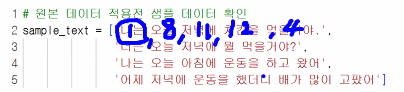

In [ ]:
# step2 : 단어사전을 기반으로 각 문장에서 단어의 빈도를 세서 변경
result = sample_cv.transform(sample_text)

In [ ]:
# 배열로 변환
result.toarray()

array([[0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0],
       [0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0],
       [1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1]])

In [ ]:
# sample_cv를 가지고 단어사전 순서 살펴보기
# 자음순서 -> 모음순서, 국어사전의 순서대로 정렬이 된다.
sample_cv.get_feature_names_out()

array(['고팠어', '나는', '너는', '많이', '먹을거야', '배가', '아침에', '어제', '오늘', '왔어',
       '운동을', '저녁에', '치킨을', '하고', '했더니'], dtype=object)

In [ ]:
pd.DataFrame(
  result.toarray(), # 벡터화 된 배열
  columns = sample_cv.get_feature_names_out()
)
# 문장에 실제로 들어있는 개수를 나타낸다
# 문장에 '나는'이 2번 들어있다면 2로 표기

,고팠어,나는,너는,많이,먹을거야,배가,아침에,어제,오늘,왔어,운동을,저녁에,치킨을,하고,했더니
0,0,1,0,0,1,0,0,0,1,0,0,1,1,0,0
1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0
2,0,1,0,0,0,0,1,0,1,1,1,0,0,1,0
3,1,0,0,1,0,1,0,1,0,0,1,1,0,0,1


### TF-IDF <BR>
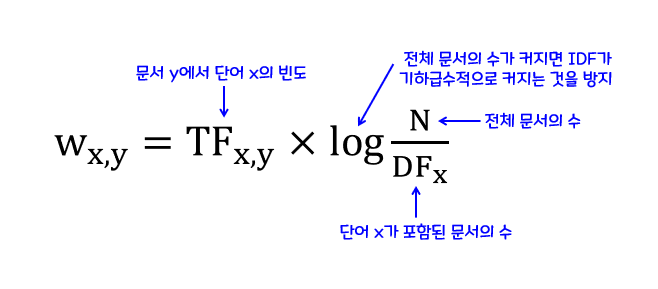

- TF(Term Frequency) : 하나의 문서에서 개별단어가 얼마나 등장하는가?
- DF(Document Frequency) : 하나의 단어가 전체 말뭉치에서 카운트한 문서중에 몇개의 문서에서 등장하는가?

In [ ]:
# TF-IDF 불러오기
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# 객체 생성
tfidf = TfidfVectorizer()
tfidf.fit(sample_text)

TfidfVectorizer()

In [ ]:
# 단어사전 확인
# 자음순서 -> 모음순서, 국어사전의 순서대로 정렬이 된다.
tfidf.vocabulary_

{'나는': 1,
 '오늘': 8,
 '저녁에': 11,
 '치킨을': 12,
 '먹을거야': 4,
 '너는': 2,
 '아침에': 6,
 '운동을': 10,
 '하고': 13,
 '왔어': 9,
 '어제': 7,
 '했더니': 14,
 '배가': 5,
 '많이': 3,
 '고팠어': 0}

In [ ]:
result = tfidf.fit_transform(sample_text).toarray()
result

array([[0.        , 0.45085176, 0.        , 0.        , 0.45085176,
        0.        , 0.        , 0.        , 0.36500336, 0.        ,
        0.        , 0.36500336, 0.57184829, 0.        , 0.        ],
       [0.        , 0.        , 0.64065543, 0.        , 0.5051001 ,
        0.        , 0.        , 0.        , 0.40892206, 0.        ,
        0.        , 0.40892206, 0.        , 0.        , 0.        ],
       [0.        , 0.36559366, 0.        , 0.        , 0.        ,
        0.        , 0.46370919, 0.        , 0.29597957, 0.46370919,
        0.36559366, 0.        , 0.        , 0.46370919, 0.        ],
       [0.40726515, 0.        , 0.        , 0.40726515, 0.        ,
        0.40726515, 0.        , 0.40726515, 0.        , 0.        ,
        0.32109252, 0.25995207, 0.        , 0.        , 0.40726515]])

In [ ]:
pd.DataFrame(
  result, # 벡터화 된 배열
  columns = tfidf.get_feature_names_out()
)

,고팠어,나는,너는,많이,먹을거야,배가,아침에,어제,오늘,왔어,운동을,저녁에,치킨을,하고,했더니
0,0.000000,0.450852,0.000000,0.000000,0.450852,0.000000,0.000000,0.000000,0.365003,0.000000,0.000000,0.365003,0.571848,0.000000,0.000000
1,0.000000,0.000000,0.640655,0.000000,0.505100,0.000000,0.000000,0.000000,0.408922,0.000000,0.000000,0.408922,0.000000,0.000000,0.000000
2,0.000000,0.365594,0.000000,0.000000,0.000000,0.000000,0.463709,0.000000,0.295980,0.463709,0.365594,0.000000,0.000000,0.463709,0.000000
3,0.407265,0.000000,0.000000,0.407265,0.000000,0.407265,0.000000,0.407265,0.000000,0.000000,0.321093,0.259952,0.000000,0.000000,0.407265


[0.        , 0.45085176, 0.        , 0.        , 0.45085176,
        0.        , 0.        , 0.        , 0.36500336, 0.        ,
        0.        , 0.36500336, 0.57184829, 0.        , 0.        ]<br>
=> "치킨을" 특정문서에서 나오는 단어의 가중치는 높게 나온다. "나는" 같은 여러 문장에서 나오는 단어의 가중치는 낮게 나온다.

### 혐오 표현 데이터 토큰화 및 수치화



In [ ]:
# kiwi에서 Stopwords 불용어 객체확인
stopwords_set = stopwords.stopwords
stopwords_set

{('ᆫ', 'ETM'),
 ('ᆫ', 'JX'),
 ('ᆫ다', 'EF'),
 ('ᆯ', 'ETM'),
 ('가', 'JKS'),
 ('같', 'VA'),
 ('것', 'NNB'),
 ('게', 'EC'),
 ('겠', 'EP'),
 ('고', 'EC'),
 ('고', 'JKQ'),
 ('과', 'JC'),
 ('과', 'JKB'),
 ('그', 'MM'),
 ('그', 'NP'),
 ('기', 'ETN'),
 ('까지', 'JX'),
 ('나', 'NP'),
 ('년', 'NNB'),
 ('는', 'ETM'),
 ('는', 'JX'),
 ('다', 'EC'),
 ('다', 'EF'),
 ('다고', 'EC'),
 ('다는', 'ETM'),
 ('대하', 'VV'),
 ('더', 'MAG'),
 ('던', 'ETM'),
 ('도', 'JX'),
 ('되', 'VV'),
 ('되', 'XSV'),
 ('들', 'XSN'),
 ('등', 'NNB'),
 ('따르', 'VV'),
 ('때', 'NNG'),
 ('때문', 'NNB'),
 ('라', 'EC'),
 ('라는', 'ETM'),
 ('로', 'JKB'),
 ('를', 'JKO'),
 ('만', 'JX'),
 ('만', 'NR'),
 ('말', 'NNG'),
 ('며', 'EC'),
 ('면', 'EC'),
 ('면서', 'EC'),
 ('명', 'NNB'),
 ('받', 'VV'),
 ('보', 'VV'),
 ('부터', 'JX'),
 ('사람', 'NNG'),
 ('성', 'XSN'),
 ('수', 'NNB'),
 ('아니', 'VCN'),
 ('않', 'VX'),
 ('어', 'EC'),
 ('어', 'EF'),
 ('어서', 'EC'),
 ('어야', 'EC'),
 ('없', 'VA'),
 ('었', 'EP'),
 ('에', 'JKB'),
 ('에게', 'JKB'),
 ('에서', 'JKB'),
 ('와', 'JC'),
 ('와', 'JKB'),
 ('우리', 'NP'),
 ('원', 'NNB'),


In [ ]:
# 불용어 사전에서 태그는 제외한 실제 단어만 뽑아오기
stopword_list = []

for word, tag in stopwords_set :
  stopword_list.append(word)

In [ ]:
stopword_list

['는',
 '과',
 '은',
 '명',
 '있',
 '한',
 'ᆯ',
 '월',
 'ᆫ',
 '며',
 '게',
 '성',
 '면서',
 '지',
 '이',
 '보',
 '있',
 '말',
 '었',
 '에',
 '나',
 '다는',
 '다',
 '겠',
 '들',
 '를',
 '받',
 '의',
 '면',
 '어서',
 '우리',
 '없',
 '적',
 '와',
 '지역',
 '것',
 '하',
 '과',
 '등',
 '때',
 'ᆫ다',
 '년',
 '되',
 '까지',
 '제',
 '다고',
 '그',
 '어',
 '고',
 '을',
 '하',
 '이',
 '은',
 '는',
 'ᆫ',
 '이',
 '중',
 '사람',
 '하',
 '을',
 '로',
 '위하',
 '던',
 '으로',
 '있',
 '일',
 '통하',
 '원',
 '더',
 '않',
 '어',
 '부터',
 '에게',
 '다',
 '때문',
 '같',
 '라',
 '어야',
 '그',
 '이',
 '기',
 '되',
 '만',
 '지만',
 '하',
 '수',
 '도',
 '대하',
 '만',
 '지',
 '이',
 '고',
 '가',
 '화',
 '주',
 '아니',
 '라는',
 '일',
 '따르',
 '에서',
 '와']

In [ ]:
# 성능 비교를 위해 2가지 종류의 단어가방 모두 사용해보기
# CountVectorizer
unsmile_cv = CountVectorizer(
  stop_words = stopword_list, # 불용어 등록
  ngram_range = (1,2),        # 유니 / 바이그램
  max_df = 0.7,               # 최대 등장 비율 -> 전체 문서중 70% 이상 등장 -> 무시
  min_df = 10                 # 특정 단어가 최소 10개 이상의 문서에서 등장 -> 고려
  )

# tfidfVectorizer
unsmile_tfidf = TfidfVectorizer(
  stop_words = stopword_list, # 불용어 등록
  ngram_range = (1,2),        # 유니 / 바이그램
  max_df = 0.7,               # 최대 등장 비율 -> 전체 문서중 70% 이상 등장 -> 무시
  min_df = 10                 # 특정 단어가 최소 10개 이상의 문서에서 등장 -> 고려
  )


In [ ]:
# 단어가방 학습
unsmile_cv.fit(morphs_train_list)
unsmile_tfidf.fit(morphs_train_list)
# test 데이터셋은 모델의 성능을 평가하는데 사용
# 사전에 모델이 test 데이터셋의 정보를 알지 못하게 하는 것이 중요

TfidfVectorizer(max_df=0.7, min_df=10, ngram_range=(1, 2),
                stop_words=['는', '과', '은', '명', '있', '한', 'ᆯ', '월', 'ᆫ', '며',
                            '게', '성', '면서', '지', '이', '보', '있', '말', '었', '에',
                            '나', '다는', '다', '겠', '들', '를', '받', '의', '면', '어서', ...])

In [ ]:
# 빈도 기반 단어사전 변환
X_train_cv = unsmile_cv.transform(morphs_train_list)
X_test_cv = unsmile_cv.transform(morphs_test_list)

In [ ]:
# tfidf 기반 단어사전 변환
X_train_tfidf = unsmile_tfidf.transform(morphs_train_list)
X_test_tfidf = unsmile_tfidf.transform(morphs_test_list)

### 단어사전 구축에 사용되는 함수 목록
- fit() : 단어사전 구축 함수
- transform() : 구축된 단어사전을 가지고 실제 문장을 변환하는 함수
- fit_transform() : 단어사전 구축 함수 + 구축된 단어사전을 가지고 실제 문장을 변환하는 함수 <br>
-> fit_transform()은 사용 할때 고려할 점이 많음<br><br>
문장데이터 구조<br>
train = 훈련용 문장데이터
test = 평가용 문장데이터 <br><br>
fit_transform을 둘다 적용 했을때 문제점
1. train -> train의 패턴을 학습하고 바로 변환(문제가 안됨)
2. test -> 기존의 train패턴을 지우고 test패턴을 재학습한 다음 바로 변환
> 평가 데이터에서 fit_transform을 사용하는 경우 기존에 학습된 train의 패턴과는 다른 형식의
   패턴이 만들어짐<br>
> 예측할 때 다른 규칙으로 변환된 평가 데이터가 들어감<br>
> 변환 기준이 다르기때문에 예측 제대로 안됨


### 정답 데이터 추출
- 현재 정답데이터는 복잡한 구조를 가지고 있다.
- 이를 단순화 시켜보자.
1. 혐오표현 : 0
2. 악플&욕설 : 1
3. clean : 2

"개인 지침"은 기존 혐오 표현에 추가된 레이블 -> 제외

In [ ]:
train.columns

Index(['문장', '여성/가족', '남성', '성소수자', '인종/국적', '연령', '지역', '종교', '기타 혐오',
       '악플/욕설', 'clean', '개인지칭'],
      dtype='object')

In [ ]:
# 혐오표현에 대한 라벨 병합
train['혐오표현'] = train.loc[:, '여성/가족':'기타 혐오'].sum(axis=1)
test['혐오표현'] = test.loc[:, '여성/가족':'기타 혐오'].sum(axis=1)


In [ ]:
train.head()

,문장,여성/가족,남성,성소수자,인종/국적,연령,지역,종교,기타 혐오,악플/욕설,clean,개인지칭,혐오표현
0,일안하는 시간은 쉬고싶어서 그런게 아닐까,0,0,0,0,0,0,0,0,0,1,0,0
1,아동성범죄와 페도버는 기록바 끊어져 영원히 고통 받는다. 무슬림 50퍼 근친이다. ...,0,0,0,0,0,0,1,0,0,0,0,1
2,루나 솔로앨범 나왔을 때부터 머모 기운 있었음 ㅇㅇ Keep o doin 진짜 띵...,0,0,0,0,0,0,0,0,0,1,0,0
3,홍팍에도 어버이연합인가 보내요 뭐 이런뎃글 있는데 이거 어버이연합측에 신고하면 그쪽...,0,0,0,0,0,0,0,0,0,1,0,0
4,아놔 왜 여기 댓들은 다 여자들이 김치녀라고 먼저 불렸다! 여자들은 더 심하게 그런...,1,0,0,0,0,0,0,0,0,0,0,1


In [ ]:
new_train = train[['문장','혐오표현','악플/욕설','clean']]
new_test = test[['문장','혐오표현','악플/욕설','clean']]

In [ ]:
new_train.head()

,문장,혐오표현,악플/욕설,clean
0,일안하는 시간은 쉬고싶어서 그런게 아닐까,0,0,1
1,아동성범죄와 페도버는 기록바 끊어져 영원히 고통 받는다. 무슬림 50퍼 근친이다. ...,1,0,0
2,루나 솔로앨범 나왔을 때부터 머모 기운 있었음 ㅇㅇ Keep o doin 진짜 띵...,0,0,1
3,홍팍에도 어버이연합인가 보내요 뭐 이런뎃글 있는데 이거 어버이연합측에 신고하면 그쪽...,0,0,1
4,아놔 왜 여기 댓들은 다 여자들이 김치녀라고 먼저 불렸다! 여자들은 더 심하게 그런...,1,0,0


### 20260316

In [ ]:
# 정답 라벨링 함수 제작
# 0 : 혐오표현
# 1 : 악플/욕설
# 2 : clean
def label(row) :
  if row['혐오표현'] > 0 :
    return 0
  elif row['악플/욕설'] > 0 :
    return 1
  else : return 2

In [ ]:
# 정답 변환하기
y_train = new_train.apply(label, axis = 1)
y_test = new_test.apply(label, axis=1)

In [ ]:
y_train.value_counts()

,count
0,8121
2,3741
1,3143


In [ ]:
# 교차검증 진행

# 모델은 선형 분류
from sklearn.linear_model import LogisticRegression
# 5조각으로 나눠서 교차검증 진행
from sklearn.model_selection import cross_val_score

In [ ]:
# 모델 객체 생성
logi = LogisticRegression(max_iter = 10000) # max_iter = 학습 반복 횟수

In [ ]:
# CountVectorize 와 TfidfVectorize 성능 비교
score_Bow = cross_val_score(logi, X_train_cv, y_train, cv = 5)
score_Bow.mean()
# 결과> 기대성능 약 62%

np.float64(0.6229923358880373)

In [ ]:
score_tfidf = cross_val_score(logi, X_train_tfidf, y_train, cv = 5)
score_tfidf.mean()
# 결과> 기대성능 약 63%

np.float64(0.6306564478507164)

In [ ]:
# 두 모델의 기대성능이 비슷한이유?

# 희소표현 방식으로 텍스트를 수치화
# 만약 저 위의 문장 묶음에서 10000개의 단어가 나옴
# 이중에서 사과라는 단어 하나를 표현하기 위해서는 어떻게 데이터를 구성 해야 하나?
# 희소표현방식 1개의 1과 9999개의 0으로 사과를 표현한다
# -> 사과를 찾기위해 10000개의 모든 데이터를 뒤져봐야 한다.
# -> 사과라는 단어와 다른 단어간의 연관 관계는 무시 -> 단순 빈도만 체크하기 때문.
# 눈치없는 분석가 같은 포지션이 되었다.
# 추후에 워드 임베딩을 통해서 더 나은 결과를 도출

In [ ]:
# 성능 개선을 위해 설정 가능 한 것들이 있다.
# -> 하이퍼파라미터 튜닝

In [ ]:
# 우리는 손으로 하이퍼파라미터 튜닝을 진행했다.
# 이제 컴퓨터에게 추천값을 받아보자.
# Pipeline, GridSearchCV의 기능
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [ ]:
# 토크나이저 + 분석모델 을 하나로 통합
# Pipeline 기능
unsmile_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=stopword_list)),
    ('logi', LogisticRegression(max_iter=10000))
])

In [ ]:
# Pipeline의 하이퍼파라미터 제어하기
# 하이퍼파라미터 목록 구성
param_grid = {
    'tfidf__max_df' : [0.5, 0.7 ,0.9],
    # 단어가 전체 문서중 최대 몇% 이상의 문서에 등장하면 단어를 제외시킬 것인지?
    'tfidf__min_df' : [3, 5, 7, 10],
    # 단어가 최소 몇개 문서에서 등장해야 하나?
    'tfidf__ngram_range' : [(1,1), (1,2), (1,3)],
    # 단어 몇개를 묶어서 하나의 단어처럼 볼까? : ngram지정
    'logi__C' : [0.01, 0.1, 1, 10]
    # 규제 강도의 역수 설정
}

In [ ]:
# GridSearch 사용
grid = GridSearchCV(
    unsmile_pipeline, # 모델
    param_grid = param_grid, # 모델의 하이퍼파라미터 목록
    cv = 3, # 교차검증 횟수
    n_jobs = -1 # CPU 병령처리를 위한 코어 갯수 지정
)

In [ ]:
grid.fit(morphs_train_list, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words=['는', '과',
                                                                    '은', '명',
                                                                    '있', '한',
                                                                    'ᆯ', '월',
                                                                    'ᆫ', '며',
                                                                    '게', '성',
                                                                    '면서', '지',
                                                                    '이', '보',
                                                                    '있', '말',
                                                                    '었', '에',
                                                                    '나', '다는',
                                                                    '다', '겠',
                                                                    '들', '를',
                                                                    '받', '의',
                                                                    '면', '어서', ...])),
                                       ('logi',
                                        LogisticRegression(max_iter=10000))]),
             n_jobs=-1,
             param_grid={'logi__C': [0.01, 0.1, 1, 10],
                         'tfidf__max_df': [0.5, 0.7, 0.9],
                         'tfidf__min_df': [3, 5, 7, 10],
                         'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)]})

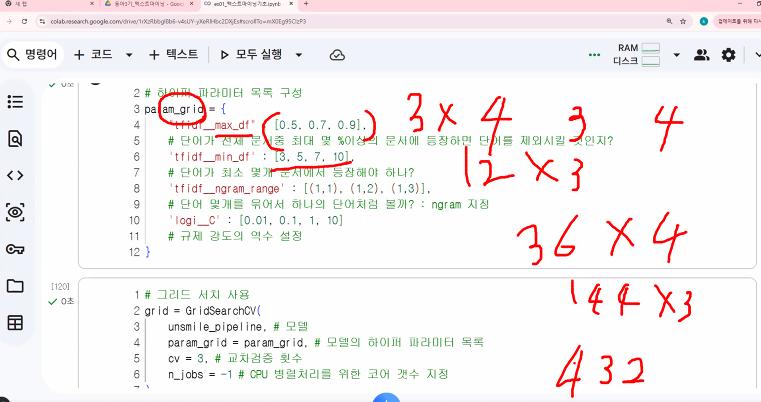

In [ ]:
# 위의 모델 검증 432번 진행
# 하이퍼파라미터 조정 경우의 수 -> 144
# 교차검증 cv=3 -> 144x3 -> 432번

In [ ]:
# 최고 점수의 하이퍼파라미터의 조합
grid.best_params_

{'logi__C': 1,
 'tfidf__max_df': 0.5,
 'tfidf__min_df': 3,
 'tfidf__ngram_range': (1, 2)}

In [ ]:
# 최고 하이퍼파라미터 조합의 교차검증 점수는 얼마?
grid.best_score_

np.float64(0.6306564623367477)

In [ ]:
# 최고 하이퍼파라미터 조합이 설정된 모델을 가져오자
best_model = grid.best_estimator_

In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/동아3기_텍스트마이닝

/content/drive/MyDrive/Colab Notebooks/동아3기_텍스트마이닝


In [ ]:
# 최고 하이퍼파라미터 모델 저장
import pickle
# pickle? -> 파이썬 객체를 파일로 저장하기 위한 Byte형태로 바꿔주는 과정
with open('./data/best_model.pkl', 'wb') as f :
  pickle.dump(best_model,f)

In [ ]:
# 최고 하이퍼파라미터 모델 불러오기
with open('./data/best_model.pkl', 'rb') as f :
  loarded_model = pickle.load(f)

In [ ]:
# 분류평가지표 살펴보기
from sklearn.metrics import classification_report # 분류평가보고서

In [ ]:
y_pred = loarded_model.predict(morphs_test_list) # 정답 예측 데이터
print(classification_report(y_test, y_pred, target_names = ['혐오표현', '악플/욕설', 'clean']))

              precision    recall  f1-score   support

        혐오표현       0.71      0.84      0.77      2016
       악플/욕설       0.52      0.26      0.35       786
       clean       0.52      0.54      0.53       935

    accuracy                           0.64      3737
   macro avg       0.59      0.55      0.55      3737
weighted avg       0.63      0.64      0.62      3737



## 1. 각 지표의 의미

| 지표        | 설명                                                                                      | 공식 / 해석                                                                                               |
|-------------|-------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------|
| **Precision (정밀도)** | 모델이 양성으로 예측한 것 중에서 실제로 양성인 비율                         | **TP / (TP + FP)** <br> 예: 0번 클래스를 혐오표현로 예측한 것 중 실제 혐오표현인 비율. <br> 높을수록 불필요한 오탐(False Positive)이 적음. |
| **Recall (재현율 / 민감도)** | 실제 양성 중에서 모델이 양성으로 올바르게 예측한 비율                 | **TP / (TP + FN)** <br> 예: 실제 혐오표현 샘플 중 혐오표현로 올바르게 예측한 비율. <br> 놓친 양성(FN)이 적을수록 좋음. |
| **F1-score** | 정밀도와 재현율의 조화 평균                                                            | **2 * (precision * recall) / (precision + recall)** <br> 정밀도와 재현율의 균형을 평가할 때 유용함. |
| **Support**  | 각 클래스에 해당하는 샘플의 수                                                           | 예: 0번 클래스(혐오표현)는 총 **2016개** 샘플. |

---

## 2. 전체 지표 해석

| 지표              | 설명                                                                                     |
|------------------|------------------------------------------------------------------------------------------|
| **Accuracy (정확도)** | 전체 예측 중 올바르게 예측한 비율 | **(TP + TN) / 전체 샘플 수** <br> 예: 3737개 샘플 중 65%를 맞춤 (0.65). |
| **Macro Avg (평균 정밀도/재현율/F1-score)** | 각 클래스별 지표의 단순 평균값을 계산 <br> (샘플 수와 상관없이 평등하게 가중치 부여) |
| **Weighted Avg (가중 평균)** | 각 클래스의 샘플 수에 비례해 평균 계산 <br> (클래스 간 불균형이 있을 때 유용) |

---

## 3. 클래스별 성능 해석

| 클래스 | 샘플 수 | Precision (정밀도) | Recall (재현율) | F1-score | 해석 |
|--------|--------|-------------------|----------------|----------|------|
| **0번 (혐오표현)** | 2016 | 0.72 | 0.85 | 0.78 | 혐오표현라고 예측한 것 중 72%가 실제 혐오표현이며, 전체 혐오표현 중 85%를 잘 예측함. |
| **1번 (악플/욕설)** | 786  | 0.52 | 0.26 | 0.34 | 악플/욕설라고 예측한 것 중 52%만 맞으며, 전체 악플/욕설 샘플 중 26%만 올바르게 예측됨. |
| **2번 (clean)** | 935  | 0.54 | 0.55 | 0.55 | clean라고 예측한 것 중 54%가 정확하며, 전체 clean 샘플의 55%를 올바르게 예측함. |

---

## 4. 정리

- **0번 클래스(혐오표현)**: 가장 좋은 성능 (F1-score: **0.78**).
- **1번 클래스(악플/욕설)**: 성능이 낮으며 특히 재현율이 낮아 많은 악플/욕설 샘플을 놓침 (F1-score: **0.34**).
- **정확도 (Accuracy)**: 전체적으로 **65%**의 샘플을 올바르게 예측.
